In [28]:

import uproot
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit
import ROOT
from colorama import Fore, Style, init
init(autoreset=True)

import numpy as np
xoffset=0
yoffset=0
paramType=False

def baseline_subtract(pulse, n_baseline=16):
    """
    Subtracts baseline from a pulse.
    n_baseline: number of samples at start used to estimate baseline
    """
    baseline = np.median(pulse[:n_baseline])
    return pulse - baseline

def GetOffSets(deltx,delty):
    poptx,_ = MakeHistogramAndFit(deltx)
    popty,_ = MakeHistogramAndFit(delty)
    print(poptx[1],popty[1])
    return poptx[1],popty[1]  
    
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))
    
def crystalball(x, alpha, n, mean, sigma, N):
    # (N = normalization)
    z = (x - mean) / sigma
    if isinstance(z, np.ndarray):
        result = np.zeros_like(z)
    else:
        result = 0

    # Transition point
    mask = z > -alpha

    # Gaussian region
    result[mask] = N * np.exp(-0.5 * z[mask]**2)

    # Power-law tail region
    A = (n / abs(alpha))**n * np.exp(-0.5 * alpha**2)
    B = n / abs(alpha) - abs(alpha)
    result[~mask] = N * A * (B - z[~mask])**(-n)

    return result

def cb_plus_const(x, alpha, n, mu, sigma, N, C):
    return crystalball(x, alpha, n, mu, sigma, N) + C

def ReadProcessedFile(filename,treeName="delTTree",paramType=True, inNanoSec=False):
    file = uproot.open(filename)
    tree = file[treeName]
    #treeData = tree.arrays(["t0","t1","t2","t3","q0","q1","q2","q3","samples0","samples2"],library="np")
    treeData = tree.arrays(["t0","t1","t2","t3","q0","q1","q2","q3","x","z"],library="np")
    param_list02=[]
    param_list13=[]
    x_list=[]#treeData["x"]
    z_list=[]#treeData["y"]
    for i in range(len(treeData["q0"])):
        if paramType:
            if not inNanoSec:
                param_list02.append((np.float64(treeData["t2"][i])-np.float64(treeData["t0"][i]))/1000.-yoffset)
                param_list13.append((np.float64(treeData["t3"][i])-np.float64(treeData["t1"][i]))/1000.-xoffset)
            else:
                param_list02.append((np.float64(treeData["t2"][i])-np.float64(treeData["t0"][i]))-yoffset)
                param_list13.append((np.float64(treeData["t3"][i])-np.float64(treeData["t1"][i]))-xoffset)
                
                
        else:
            param_list02.append(math.log(treeData["q2"][i]/treeData["q0"][i]))
            param_list13.append(math.log(treeData["q1"][i]/treeData["q3"][i]))
            
        x_list.append(treeData["x"][i])
        z_list.append(treeData["z"][i])
            
        '''
        if paramType == 0:
            param_list02.append(treeData["t0"][i]-treeData["t2"][i])
            param_list13.append(treeData["t1"][i]-treeData["t3"][i])
        elif paramType == 1:
            param_list02.append(math.log(treeData["q2"][i]/treeData["q0"][i]))
            param_list13.append(math.log(treeData["q1"][i]/treeData["q3"][i]))
        elif paramType == 2:
            pulse0=treeData["samples0"]
            pulse2=treeData["samples2"]
            for i in range(len(pulse0)):
                param_list02.append(math.log(np.min(baseline_subtract(pulse2[i]))/np.min(baseline_subtract(pulse0[i]))))
                #param_list13.append(math.log(np.min(baseline_subtract(pulse3[i]))/np.min(baseline_subtract(pulse1[i]))))
        '''
            
        
    return param_list02,param_list13,x_list,z_list

def MakeHistogramAndFit(param_list,index=0,showHist=False):
    #binss=np.linspace(-5,5,100)
    #counts, bins, _ =plt.hist(param_list,bins=binss,histtype='step',color='blue
    plt.figure()
    counts, bins, _ =plt.hist(param_list,bins=100,histtype='step',color='blue')
    max_idx = np.argmax(counts)
    bin_center = (bins[max_idx] + bins[max_idx + 1]) / 2
    #print("Bin Center : ",bin_center )

    if not showHist:
        plt.close()
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    # Initial guess for fit parameters: A, mean, sigma
    p0 = [max(counts), np.mean(param_list), np.std(param_list)]
    # Fit using curve_fit
    popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
    # Extract fit results
    A_fit, mu_fit, sigma_fit = popt
    #print(f"Fit results for file at Position={index}, A={A_fit:.2f}, mu={mu_fit:.2f}, sigma={sigma_fit:.2f}")
    return popt,bins

def PlotFit(dist,popt,bins):
    x_fit = np.linspace(min(bins), max(bins), 1000)
    y_fit = dist(x_fit, *popt)
    plt.plot(x_fit, y_fit, 'r--', linewidth=2, label='Gaussian Fit')

def FitPolynomial(listx,listy,color="b"):
    linetype=color+"--"
    plt.plot(listx,listy,"o",color='red')
    #print(listx)
    coeffs = np.polyfit(listx, listy, 3)  # degree = 3
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(listx), max(listx), 500)
    y_fit = poly(x_fit)
    plt.plot(x_fit, y_fit, linetype, label="3rd Order Fit")
    return poly
    

In [29]:

base_path="/home/rsehgal/shared/G4Simulations/NonSegmented/build/"
#fullURL="/home/rsehgal/shared/SquareScint/python_code/ProcessedData/Muon_output_0_0_data.root"
fullURL=base_path+"Muon_output_0_0_data.root"
param_list02,param_list13,xlist,zlist = ReadProcessedFile(fullURL,treeName="delTTree",paramType=paramType,inNanoSec=True)
xoffset,yoffset=GetOffSets(param_list13,param_list02)
print(xoffset,yoffset)

-0.0072751311084157805 0.004050434286169276
-0.0072751311084157805 0.004050434286169276


========= X File List ==========
[['Muon_output_-20_-20_data.root', 'Muon_output_-20_-15_data.root', 'Muon_output_-20_-10_data.root', 'Muon_output_-20_-5_data.root', 'Muon_output_-20_0_data.root', 'Muon_output_-20_5_data.root', 'Muon_output_-20_10_data.root', 'Muon_output_-20_15_data.root', 'Muon_output_-20_20_data.root'], ['Muon_output_-15_-20_data.root', 'Muon_output_-15_-15_data.root', 'Muon_output_-15_-10_data.root', 'Muon_output_-15_-5_data.root', 'Muon_output_-15_0_data.root', 'Muon_output_-15_5_data.root', 'Muon_output_-15_10_data.root', 'Muon_output_-15_15_data.root', 'Muon_output_-15_20_data.root'], ['Muon_output_-10_-20_data.root', 'Muon_output_-10_-15_data.root', 'Muon_output_-10_-10_data.root', 'Muon_output_-10_-5_data.root', 'Muon_output_-10_0_data.root', 'Muon_output_-10_5_data.root', 'Muon_output_-10_10_data.root', 'Muon_output_-10_15_data.root', 'Muon_output_-10_20_data.root'], ['Muon_output_-5_-20_data.root', 'Muon_output_-5_-15_data.root', 'Muon_output_-5_-10_data.roo

'    \n#List of X parameterization will be obtained at different fixed Y\nplt.figure(figsize=(8,8))\nplt.subplot(2,2,1)\nmean_list02=[]\nmean_list13=[]\nparamType=True\nfor index in range(len(file_list)):\n    param_list02,param_list13 = ReadProcessedFile(base_path+file_list[index],paramType=paramType)\n    \n    popt,bins=MakeHistogramAndFit(param_list02,index)\n    A_fit, mu_fit, sigma_fit = popt\n    mean_list02.append(mu_fit)\n\n    popt,bins=MakeHistogramAndFit(param_list13,index)\n    A_fit, mu_fit, sigma_fit = popt\n    mean_list13.append(mu_fit)\n'

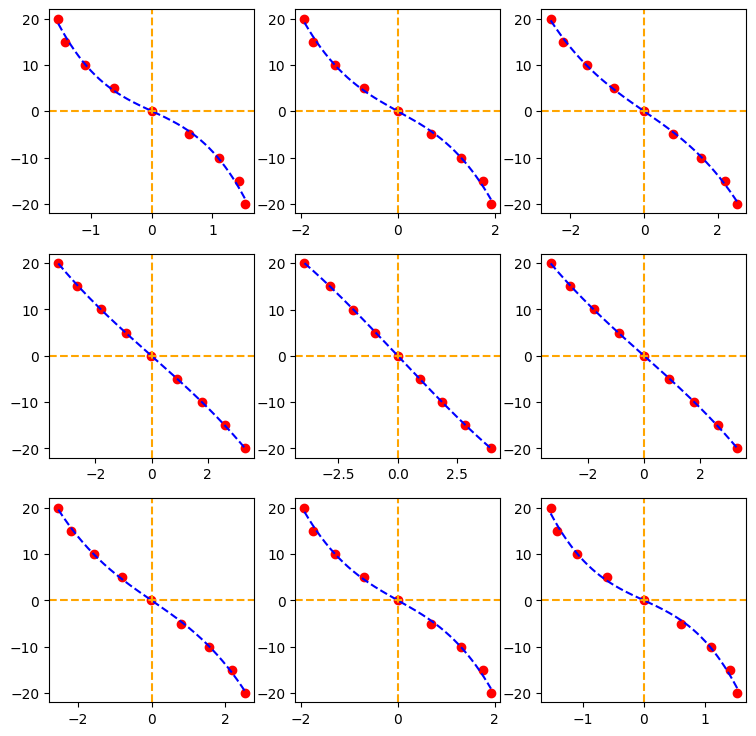

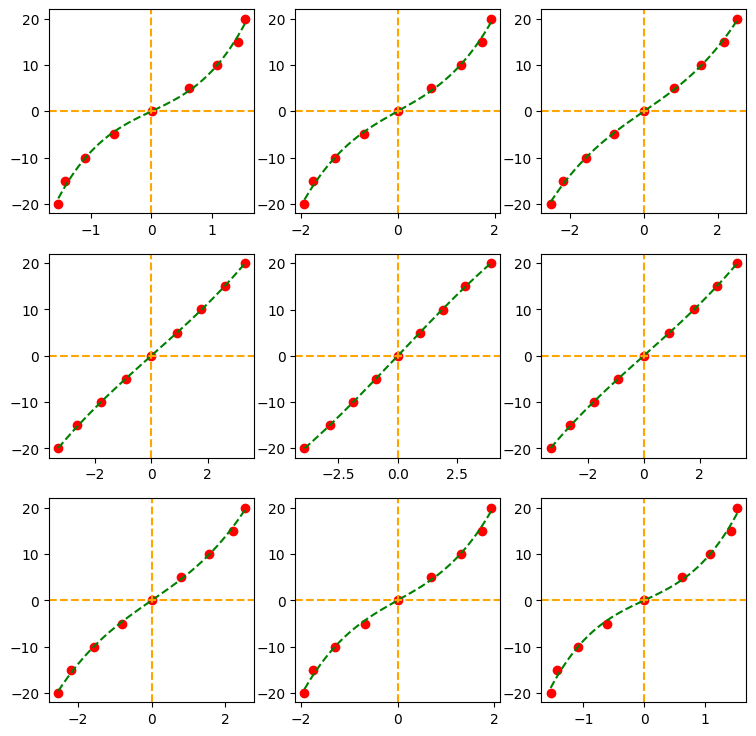

In [30]:
import os


def GetXYPos(filename):
    parts = filename.split("_")

    # Get the last 3 underscore-separated parts
    last_three = parts[-3:]  

    # Extract the first two as numbers
    num1 = last_three[0]  # could be "0"
    num2 = last_three[1]  # could be "+15"

    return int(num1),int(num2)

from sklearn.linear_model import LinearRegression

#base_path="/home/rsehgal/shared/SquareScint/python_code/ProcessedData/"
#file_list=["Muon_output_0_-20.root","Muon_output_0_-15.root","Muon_output_0_-10.root","Muon_output_0_-5.root","Muon_output_0_0.root","Muon_output_0_5.root","Muon_output_0_10.root","Muon_output_0_15.root","Muon_output_0_20.root"]
list_Of_Xfile_list=[]
list_Of_Yfile_list=[]
loc_list = [-20,-15,-10,-5,0,5,10,15,20]
#loc_list = [-20,-10,0,10,20]
X_phys = []
Y_phys = []
for i in loc_list:
    xfile_list=[]
    yfile_list=[]
    for j in loc_list:
        X_phys.append(i)
        Y_phys.append(j)
        xfile_list.append("Muon_output_"+str(i)+"_"+str(j)+"_data.root")
        yfile_list.append("Muon_output_"+str(j)+"_"+str(i)+"_data.root")
    list_Of_Xfile_list.append(xfile_list)
    list_Of_Yfile_list.append(yfile_list)

print("========= X File List ==========")
print(list_Of_Xfile_list)
print("========= Y File List ==========")
print(list_Of_Yfile_list)

'''
print("================ Going to process following files =================")
for filename in file_list:
    print(filename)

print("=============== Starting =================")
'''
#fittedPoly=FitPolynomial(mean_list,loc_list)

#List of Y parameterization will be obtained at different fixed X
plt.figure(figsize=(9,9))
counter=1

list_of_X_param=[]
list_of_Y_param=[]

for file_list in list_Of_Xfile_list:
    
    #file_list is the list of file at fixed X
    
    local_loc_list=[]
    mean_list=[]
    print("============= Processing File List X direction ================")
    print(file_list)
    for index in range(len(file_list)):
        fullURL=base_path+file_list[index]
        if os.path.exists(fullURL):
            x,y=GetXYPos(fullURL)
            local_loc_list.append(y)
            print("FullURL : ",fullURL)
            param_list02,param_list13,xlist,zlist = ReadProcessedFile(fullURL,paramType=paramType,inNanoSec=True)    
            popt,bins=MakeHistogramAndFit(param_list02,index)
            A_fit, mu_fit, sigma_fit = popt
            print(popt)
            mean_list.append(mu_fit)
            
    if len(local_loc_list) > 0:    
        plt.subplot(3,3,counter)       
        fittedPoly=FitPolynomial(mean_list,local_loc_list)
        list_of_X_param.append(fittedPoly)
        #plt.vlines(x=0, ymin=-30, ymax=30, color="orange", linestyle="--")
        plt.axvline(x=0, color="orange", linestyle="--", label="x=0")
        plt.axhline(y=0, color="orange", linestyle="--", label="x=0")
        counter += 1
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
plt.figure(figsize=(9,9))

#resetting counter
counter=1
for file_list in list_Of_Yfile_list:

    local_loc_list=[]
    #file_list is the list of file at fixed X
    mean_list=[]
    print("============= Processing File List  Y direction ================")
    print(file_list)
    for index in range(len(file_list)):
        fullURL=base_path+file_list[index]
        if os.path.exists(fullURL):
            x,y=GetXYPos(fullURL)
            local_loc_list.append(x)
            print("FullURL : ",fullURL)
            param_list02,param_list13,xlist,zlist = ReadProcessedFile(fullURL,paramType=paramType,inNanoSec=True)    
            popt,bins=MakeHistogramAndFit(param_list13,index)
            A_fit, mu_fit, sigma_fit = popt
            print(popt)
            mean_list.append(mu_fit)

    if len(local_loc_list) > 0:
        plt.subplot(3,3,counter)       
        fittedPoly=FitPolynomial(mean_list,local_loc_list,color="g")
        list_of_Y_param.append(fittedPoly)
        plt.axvline(x=0, color="orange", linestyle="--", label="x=0")
        plt.axhline(y=0, color="orange", linestyle="--", label="x=0")
        counter += 1
'''    
#List of X parameterization will be obtained at different fixed Y
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
mean_list02=[]
mean_list13=[]
paramType=True
for index in range(len(file_list)):
    param_list02,param_list13 = ReadProcessedFile(base_path+file_list[index],paramType=paramType)
    
    popt,bins=MakeHistogramAndFit(param_list02,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list02.append(mu_fit)

    popt,bins=MakeHistogramAndFit(param_list13,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list13.append(mu_fit)
'''

[565.7569609   15.53019451   4.00964959]
[464.25279702   7.80794256   2.56549302]


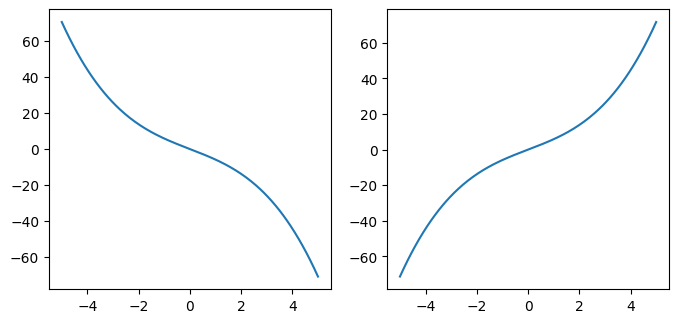

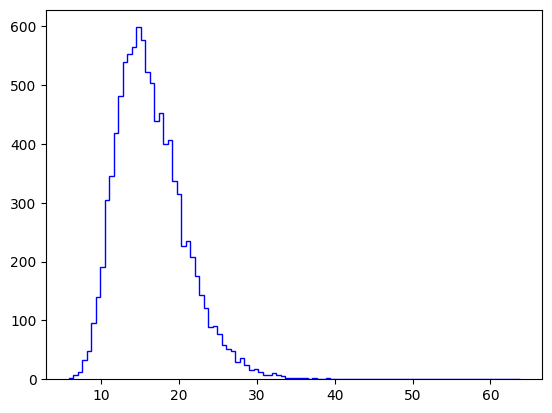

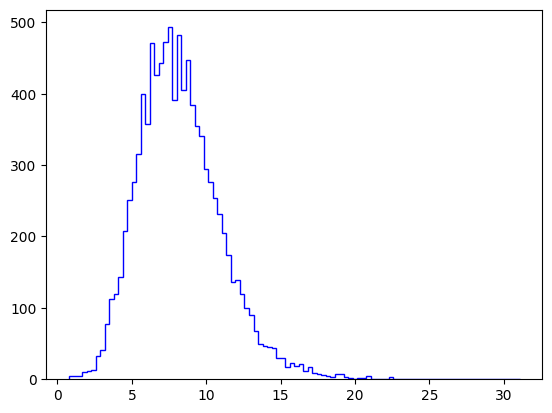

In [31]:
xval = np.linspace(-5,5,200)
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.plot(xval, list_of_X_param[2](xval))
plt.subplot(2,2,2)
plt.plot(xval, list_of_Y_param[2](xval))

#fullURL="/home/rsehgal/shared/SquareScint/python_code/ProcessedData/Muon_output_15_10_data.root"
fullURL=base_path+"Muon_output_10_15_data.root"
param_list02,param_list13,xlist,zlist = ReadProcessedFile(fullURL,treeName="delTTree",paramType=paramType,inNanoSec=True)
evaluatedValuesAlongY = list_of_X_param[2](param_list02)
evaluatedValuesAlongX = list_of_Y_param[2](param_list13)
#plt.subplot(2,2,3)
popt,bins=MakeHistogramAndFit(evaluatedValuesAlongY,showHist=True)
print(popt)
binss=np.linspace(-50,50,100)
#plt.hist(evaluatedValuesAlongY,bins=binss,histtype='step')
#plt.subplot(2,2,4)
popt,bins=MakeHistogramAndFit(evaluatedValuesAlongX,showHist=True)
print(popt)
#plt.hist(evaluatedValuesAlongX,bins=binss,histtype='step')
plt.show()

In [33]:

import numpy as np

# --- Example: assume these come from your calibration fit step ---
# dTx_cal, dTy_cal, X_true, Y_true were used to build A and fit coeffs
# Here we reuse build_design_matrix from earlier answer (total-degree <= order)
def build_design_matrix(dTx, dTy, order=3):
    dTx = np.asarray(dTx)
    dTy = np.asarray(dTy)
    terms = []
    exponents = []
    for i in range(order + 1):
        for j in range(order + 1 - i):
            terms.append((dTx ** i) * (dTy ** j))
            exponents.append((i, j))
    A = np.vstack(terms).T
    return A, exponents

# ---------- Fit on calibration data (one-time) ----------
# replace these with your actual calibration arrays
'''
N = 25
np.random.seed(0)
dTx_cal = np.random.uniform(-5, 5, N)
dTy_cal = np.random.uniform(-5, 5, N)
X_true = 10 + 2*dTx_cal - 0.5*dTy_cal + 0.1*dTx_cal*dTy_cal + 0.01*dTx_cal**2 + np.random.normal(0,0.2,N)
Y_true = -8 + 1.5*dTy_cal + 0.3*dTx_cal*dTy_cal - 0.02*dTy_cal**2 + np.random.normal(0,0.2,N)
'''

#base_path="/home/rsehgal/shared/SquareScint/python_code/ProcessedData/"
file_list=[]
loc_list = [-20,-10,0,10,20]
X_true = []
Y_true = []
for i in loc_list:
    for j in loc_list:
        X_true.append(i)
        Y_true.append(j)
        file_list.append("Muon_output_"+str(i)+"_"+str(j)+"_data.root")
print(len(file_list))
dTx_cal=[]
dTy_cal=[]

for index in range(len(file_list)):
    param_list02,param_list13,xlist,zlist = ReadProcessedFile(base_path+file_list[index],treeName="delTTree",paramType=paramType,inNanoSec=True)
    
    popt,bins=MakeHistogramAndFit(param_list02,index)
    A_fit, mu_fit, sigma_fit = popt
    dTy_cal.append(mu_fit)

    popt,bins=MakeHistogramAndFit(param_list13,index)
    A_fit, mu_fit, sigma_fit = popt
    dTx_cal.append(mu_fit)

print(len(dTx_cal))
print(len(dTx_cal))

order = 3
A_cal, exponents = build_design_matrix(dTx_cal, dTy_cal, order=order)

# coefficients (solved once)
coeffs_x, _, _, _ = np.linalg.lstsq(A_cal, X_true, rcond=None)
coeffs_y, _, _, _ = np.linalg.lstsq(A_cal, Y_true, rcond=None)

# estimate residual variance (sigma^2) and parameter covariance
resid_x = X_true - A_cal.dot(coeffs_x)
resid_y = Y_true - A_cal.dot(coeffs_y)
dof = max(1, len(X_true) - A_cal.shape[1])  # avoid div-by-zero

sigma2_x = np.sum(resid_x**2) / dof
sigma2_y = np.sum(resid_y**2) / dof

# covariance of fit parameters ~ sigma^2 * (A^T A)^{-1}
ATA_inv = np.linalg.inv(A_cal.T.dot(A_cal))
cov_params_x = sigma2_x * ATA_inv
cov_params_y = sigma2_y * ATA_inv

# ---------- Per-event prediction with uncertainty ----------
def feature_vector(dTx_val, dTy_val, exponents):
    """Return vector of polynomial basis evaluated at one point (shape: [n_terms,])"""
    fv = np.array([(dTx_val**i) * (dTy_val**j) for (i,j) in exponents])
    return fv

def predict_with_uncertainty(dTx_val, dTy_val, coeffs, cov_params, exponents):
    """
    Returns (prediction, sigma_pred) for one event.
    sigma_pred = sqrt( J^T * Cov_params * J )
    where J is the basis (feature) vector at the evaluation point.
    """
    fv = feature_vector(dTx_val, dTy_val, exponents)
    pred = float(fv.dot(coeffs))
    var_pred = float(fv.dot(cov_params).dot(fv))
    sigma_pred = np.sqrt(max(0.0, var_pred))
    return pred, sigma_pred

# Example: event-by-event usage
# Suppose this is one muon event from DAQ:
dTx_event = 0.7   # microseconds or whichever units your ΔT uses
dTy_event = -1.3

x_event, x_sigma = predict_with_uncertainty(dTx_event, dTy_event, coeffs_x, cov_params_x, exponents)
y_event, y_sigma = predict_with_uncertainty(dTx_event, dTy_event, coeffs_y, cov_params_y, exponents)

print(f"Predicted (x, y) = ({x_event:.2f} ± {x_sigma:.2f}, {y_event:.2f} ± {y_sigma:.2f})")


25
25
25
Predicted (x, y) = (6.28 ± 2.08, 10.67 ± 2.08)


Size of paramlist_02 :  49996
Size of paramlist_13 :  49996
Size of Xlist :  49996
Size of Zlist :  49996
[643.57718013   1.84054423  21.32654343]
[641.42654155  -1.65060715  21.32801896]
StdDev of resiX :  4.110140247275704
StdDev of resiZ :  4.100293504131931


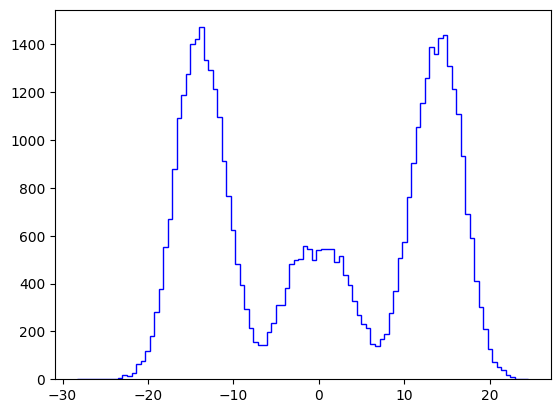

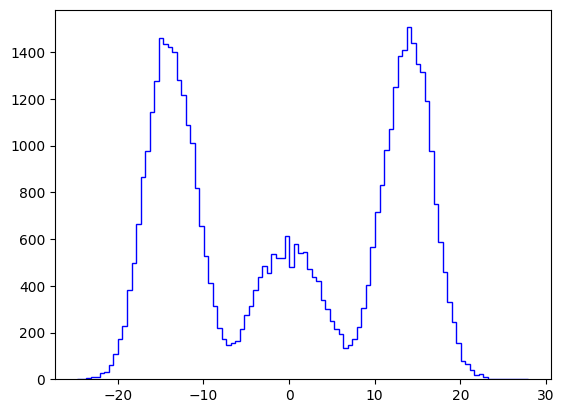

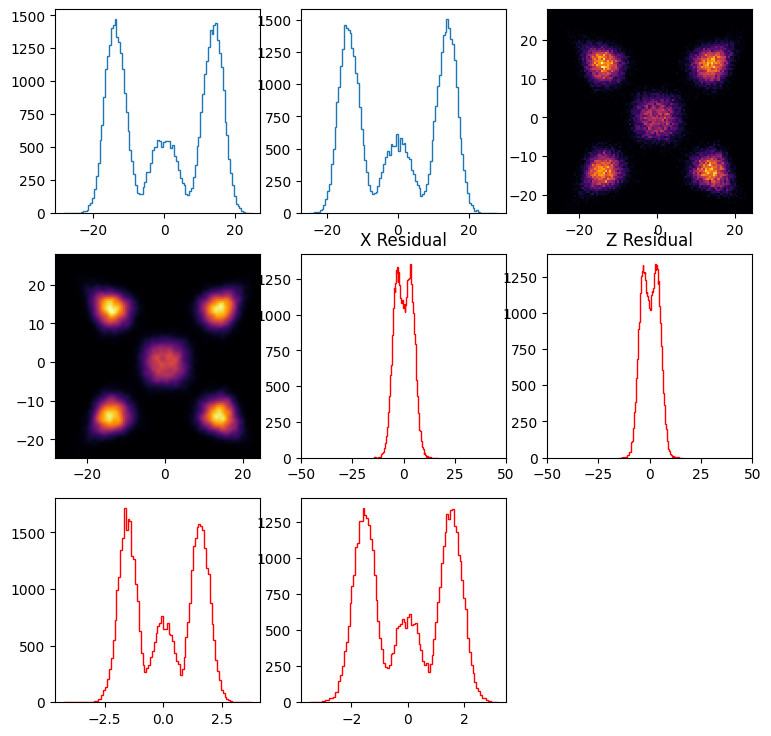

In [39]:

#fullURL="/home/rsehgal/shared/SquareScint/python_code/ProcessedData/Muon_output_10_10_data.root"
#base_path="/home/rsehgal/shared/SquareScint/python_code/ProcessedData/"
base_path="/home/rsehgal/shared/G4Simulations/NonSegmented/build/"
#fullURL=base_path+"Muon_output_0_0_data.root"
fullURL=base_path+"combined.root"
#fullURL=base_path+"combined.root"
#param_list02,param_list13 = ReadProcessedFile(fullURL,treeName="treeML",paramType=paramType,inNanoSec=False)
param_list02,param_list13,xlist,zlist = ReadProcessedFile(fullURL,treeName="delTTree",paramType=paramType,inNanoSec=True)
predictedX=[]
predictedY=[]
resiX=[]
resiZ=[]

print("Size of paramlist_02 : ",len(param_list02))
print("Size of paramlist_13 : ",len(param_list13))
print("Size of Xlist : ",len(xlist))
print("Size of Zlist : ",len(zlist))
'''
c = ROOT.TCanvas("c", "2D Histogram Example", 800, 600)
h2 = ROOT.TH2F("h2", "2D Histogram;x-axis;y-axis", 140, -35, 35, 140, -35, 35)
'''
for index in range(len(param_list02)):
    x_event, x_sigma = predict_with_uncertainty(param_list13[index], param_list02[index], coeffs_x, cov_params_x, exponents)
    y_event, y_sigma = predict_with_uncertainty(param_list13[index], param_list02[index], coeffs_y, cov_params_y, exponents)

    #Some correction based on observation, but it is not uniform throughout, hence needs to be applied based on calculated value
    '''
    if x_event < 0:
        x_event += 2
    else:
        x_event -= 2

    if y_event < 0:
        y_event += 2
    else:
        y_event -= 2
    '''    
    predictedX.append(x_event)
    predictedY.append(y_event)
    resiX.append(xlist[index]/10.-x_event)
    resiZ.append(zlist[index]/10.-y_event)
    
    #h2.Fill(x_event,y_event)
'''
h2.Draw("COLZ") 
c.Update()
c.SaveAs("hist2d.png")
'''
popt,bins=MakeHistogramAndFit(predictedX,showHist=True)
print(popt)

popt,bins=MakeHistogramAndFit(predictedY,showHist=True)
print(popt)

plt.figure(figsize=(9,9))
plt.subplot(3,3,1)
plt.hist(predictedX,histtype='step',bins=100)

plt.subplot(3,3,2)
plt.hist(predictedY,histtype='step',bins=100)

#plt.subplot(2,3,3)
#plt.scatter(predictedX,predictedY,marker=".")

from matplotlib.colors import LogNorm
plt.subplot(3,3,3)
hist = plt.hist2d(predictedX,predictedY, bins=100, cmap="inferno")#,norm=LogNorm())

from scipy.ndimage import gaussian_filter
plt.subplot(3,3,4)
H, xedges, yedges = np.histogram2d(predictedX,predictedY, bins=100)
# Smooth with Gaussian filter
H_smooth = gaussian_filter(H, sigma=1.0)  # sigma controls smoothing strength

# Plot smoothed histogram
plt.imshow(H_smooth.T, origin="lower",
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           cmap="inferno", aspect="auto")

plt.subplot(3,3,5)
plt.hist(resiX,histtype="step",color="red",bins=100)
plt.xlim(-50,50)
plt.title("X Residual")
print("StdDev of resiX : ",np.std(resiX))


plt.subplot(3,3,6)
plt.hist(resiZ,histtype="step",color="red",bins=100)
plt.xlim(-50,50)
plt.title("Z Residual")
print("StdDev of resiZ : ",np.std(resiZ))

plt.subplot(3,3,7)
plt.hist(param_list02,histtype="step",color="red",bins=100)

plt.subplot(3,3,8)
plt.hist(param_list13,histtype="step",color="red",bins=100)



import ROOT
plt.show()
    

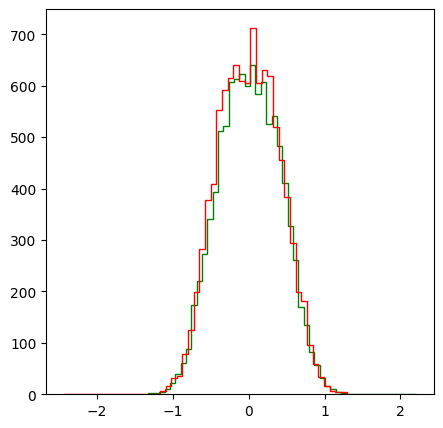

In [19]:

base_path="/home/rsehgal/shared/G4Simulations/NonSegmented/build/"
fullURL=base_path+"Muon_output_0_0_data.root"
#fullURL=base_path+"combined.root"
paramType=False
#param_list02,param_list13 = ReadProcessedFile(fullURL,treeName="treeML",paramType=paramType,inNanoSec=False)
param_list02,param_list13,xlist,zlist = ReadProcessedFile(fullURL,treeName="delTTree",paramType=paramType,inNanoSec=True)
plt.figure(figsize=(5,5))
plt.hist(param_list02,histtype='step',color="green",bins=50)
plt.hist(param_list13,histtype='step',color="red",bins=50)
plt.show()

In [12]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D

from sklearn.linear_model import LinearRegression
paramType=True
#base_path="/home/rsehgal/shared/SquareScint/CPP/build/"
#file_list=["Muon_output_0_-20.root","Muon_output_0_-15.root","Muon_output_0_-10.root","Muon_output_0_-5.root","Muon_output_0_0.root","Muon_output_0_5.root","Muon_output_0_10.root","Muon_output_0_15.root","Muon_output_0_20.root"]
list_Of_Xfile_list=[]
list_Of_Yfile_list=[]
#loc_list = [-20,-15,-10,-5,0,5,10,15,20]
loc_list = [-20,-10,0,10,20]
X_phys = []
Y_phys = []
for i in loc_list:
    for j in loc_list:
        X_phys.append(i)
        Y_phys.append(j)
        file_list.append("Muon_output_"+str(i)+"_"+str(j)+".root")
print(len(file_list))
mean_list02=[]
mean_list13=[]
paramType=True
for index in range(len(file_list)):
    param_list02,param_list13 = ReadProcessedFile(base_path+file_list[index],paramType=paramType)
    
    popt,bins=MakeHistogramAndFit(param_list02,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list02.append(mu_fit)

    popt,bins=MakeHistogramAndFit(param_list13,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list13.append(mu_fit)

print(len(mean_list02))
print(len(mean_list13))
# === Replace these with your 25 calibration points ===
# Example placeholders (length 25)
delTx = np.array(mean_list13) # ([/* 25 values */])
delTy = np.array(mean_list02) # ([/* 25 values */])
x_true = np.array(X_phys) # ([/* 25 true x positions */])
y_true = np.array(Y_phys) # ([/* 25 true y positions */])

print(delTx.shape)

# Prepare feature matrix
X = np.vstack([delTx, delTy]).T

# Try degrees and compare with CV
for deg in (1, 2, 3):
    poly = PolynomialFeatures(degree=deg, include_bias=True)
    Xp = poly.fit_transform(X)
    model_x = LinearRegression().fit(Xp, x_true)
    model_y = LinearRegression().fit(Xp, y_true)
    # simple cv score on x and y
    scores_x = cross_val_score(LinearRegression(), Xp, x_true, cv=5, scoring='r2')
    scores_y = cross_val_score(LinearRegression(), Xp, y_true, cv=5, scoring='r2')
    print(f"deg={deg}: R2_x mean={scores_x.mean():.3f}, R2_y mean={scores_y.mean():.3f}")

# Pick a degree (say deg=2)
deg = 2
poly = PolynomialFeatures(degree=deg, include_bias=True)
Xp = poly.fit_transform(X)
model_x = LinearRegression().fit(Xp, x_true)
model_y = LinearRegression().fit(Xp, y_true)

# Function to predict position from new (delTx, delTy)
def predict_position(dtx, dty):
    v = np.array([[dtx, dty]])
    vp = poly.transform(v)
    x_pred = model_x.predict(vp)[0]
    y_pred = model_y.predict(vp)[0]
    return x_pred, y_pred

# Example predict
dtx_sample, dty_sample = 0.123, -0.045
print("predicted (x,y):", predict_position(dtx_sample, dty_sample))

# --- Optional: plot fitted surface for x (and similarly for y) ---
# create a grid
grid_n = 50
dtx_lin = np.linspace(delTx.min(), delTx.max(), grid_n)
dty_lin = np.linspace(delTy.min(), delTy.max(), grid_n)
D1, D2 = np.meshgrid(dtx_lin, dty_lin)
grid_pts = np.vstack([D1.ravel(), D2.ravel()]).T
grid_p = poly.transform(grid_pts)
X_surf = model_x.predict(grid_p).reshape(D1.shape)
Y_surf = model_y.predict(grid_p).reshape(D1.shape)

fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(D1, D2, X_surf, alpha=0.7)
ax.scatter(delTx, delTy, x_true, color='r')
ax.set_xlabel('delTx'); ax.set_ylabel('delTy'); ax.set_zlabel('x_true'); ax.set_title('Fitted surface -> x')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(D1, D2, Y_surf, alpha=0.7)
ax2.scatter(delTx, delTy, y_true, color='r')
ax2.set_xlabel('delTx'); ax2.set_ylabel('delTy'); ax2.set_zlabel('y_true'); ax2.set_title('Fitted surface -> y')

plt.tight_layout()
plt.show()


50


ValueError: too many values to unpack (expected 2)

FileNotFoundError: [Errno 2] No such file or directory: '/home/rsehgal/shared/SquareScint/CPP/build/Muon_output_0_-20.root'

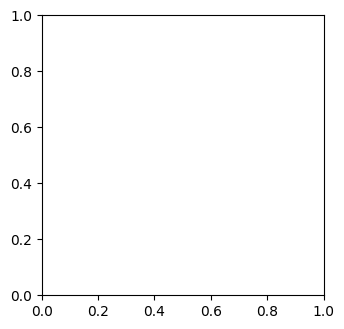

In [13]:
base_path="/home/rsehgal/shared/SquareScint/CPP/build/"
file_list=["Muon_output_0_-20.root","Muon_output_0_-15.root","Muon_output_0_-10.root","Muon_output_0_-5.root","Muon_output_0_0.root","Muon_output_0_5.root","Muon_output_0_10.root","Muon_output_0_15.root","Muon_output_0_20.root"]
loc_list = [-20,-15,-10,-5,0,5,10,15,20]

#file_list=["Muon_output_-10_-20.root","Muon_output_-10_-10.root","Muon_output_-10_0.root","Muon_output_-10_10.root","Muon_output_-10_20.root"]
#loc_list = [-20,-10,0,10,20]

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
mean_list=[]
paramType=True
for index in range(len(file_list)):
    param_list02,param_list13 = ReadProcessedFile(base_path+file_list[index],paramType=paramType)
    popt,bins=MakeHistogramAndFit(param_list02,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list.append(mu_fit)
    #PlotFit(gaussian,popt,bins)

plt.subplot(2,2,2)
fittedPoly=FitPolynomial(mean_list,loc_list)
param_list02,param_list13 = ReadProcessedFile(base_path+file_list[4],paramType=paramType)
evaluatedResult=fittedPoly(param_list02)
print("Mean of Evaluated : ",np.mean(evaluatedResult))
print("Sigma of Evaluated : ",np.std(evaluatedResult))

plt.subplot(2,2,3)
plt.hist(evaluatedResult,bins=100,histtype='step',color='blue')
    
'''
plt.subplot(2,2,2)
param_list02,param_list13 = ReadProcessedFile(base_path+file_list[5],timing=True)
popt,bins=MakeHistogramAndFit(param_list02)
PlotFit(gaussian,popt,bins)
'''
#plt.hist(param_list02,bins=100,histtype='step', color='blue')
plt.show()



In [ ]:
from sklearn.linear_model import LinearRegression

base_path="/home/rsehgal/shared/SquareScint/CPP/build/"
file_list=["Muon_output_0_-20.root","Muon_output_0_-15.root","Muon_output_0_-10.root","Muon_output_0_-5.root","Muon_output_0_0.root","Muon_output_0_5.root","Muon_output_0_10.root","Muon_output_0_15.root","Muon_output_0_20.root"]
file_list=[]
#loc_list = [-20,-15,-10,-5,0,5,10,15,20]
loc_list = [-20,-10,0,10,20]
X_phys = []
Y_phys = []
for i in loc_list:
    for j in loc_list:
        X_phys.append(i)
        Y_phys.append(j)
        file_list.append("Muon_output_"+str(i)+"_"+str(j)+".root")

'''
print("================ Going to process following files =================")
for filename in file_list:
    print(filename)

print("=============== Starting =================")
'''
#file_list=["Muon_output_-10_-20.root","Muon_output_-10_-10.root","Muon_output_-10_0.root","Muon_output_-10_10.root","Muon_output_-10_20.root"]
#loc_list = [-20,-10,0,10,20]

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
mean_list02=[]
mean_list13=[]
paramType=True
for index in range(len(file_list)):
    param_list02,param_list13 = ReadProcessedFile(base_path+file_list[index],paramType=paramType)
    
    popt,bins=MakeHistogramAndFit(param_list02,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list02.append(mu_fit)

    popt,bins=MakeHistogramAndFit(param_list13,index)
    A_fit, mu_fit, sigma_fit = popt
    mean_list13.append(mu_fit)
    

plt.subplot(2,2,2)
plt.plot(mean_list13,mean_list02,"o", color='red')
plt.xlim(-5,5)
plt.ylim(-5,5)

# ----------------------
# Fit planes using least squares
# ----------------------
A = np.column_stack([mean_list13, mean_list02, np.ones_like(mean_list13)])

coef_x, *_ = np.linalg.lstsq(A, X_phys, rcond=None)  # plane coefficients for X_phys
coef_y, *_ = np.linalg.lstsq(A, Y_phys, rcond=None)  # plane coefficients for Y_phys

print(f"Plane for X_phys: X = {coef_x[0]:.3f}*ΔTx + {coef_x[1]:.3f}*ΔTy + {coef_x[2]:.3f}")
print(f"Plane for Y_phys: Y = {coef_y[0]:.3f}*ΔTx + {coef_y[1]:.3f}*ΔTy + {coef_y[2]:.3f}")

# ----------------------
# Make a grid for smooth surface
# ----------------------
grid_tx = np.linspace(np.min(mean_list13), np.max(mean_list13), 30)
grid_ty = np.linspace(np.min(mean_list02), np.max(mean_list02), 30)
GTX, GTY = np.meshgrid(grid_tx, grid_ty)

GX = coef_x[0]*GTX + coef_x[1]*GTY + coef_x[2]  # plane for X_phys
GY = coef_y[0]*GTX + coef_y[1]*GTY + coef_y[2]  # plane for Y_phys

# ----------------------
# Plot 1: Plane for X_phys
# ----------------------
fig1 = plt.figure(figsize=(7, 6))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot_surface(GTX, GTY, GX, alpha=0.6, cmap='viridis')
ax1.scatter(mean_list13, mean_list02, X_phys, color='red')  # calibration points
ax1.set_xlabel("ΔT_x")
ax1.set_ylabel("ΔT_y")
ax1.set_zlabel("X_phys")
ax1.set_title("Calibration Plane for X_phys")

# ----------------------
# Plot 2: Plane for Y_phys
# ----------------------
fig2 = plt.figure(figsize=(7, 6))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.plot_surface(GTX, GTY, GY, alpha=0.6, cmap='plasma')
ax2.scatter(mean_list13, mean_list02, Y_phys, color='blue')  # calibration points
ax2.set_xlabel("ΔT_x")
ax2.set_ylabel("ΔT_y")
ax2.set_zlabel("Y_phys")
ax2.set_title("Calibration Plane for Y_phys")

GTX=-2.0
GTY=2.5
GX = coef_x[0]*GTX + coef_x[1]*GTY + coef_x[2]  # plane for X_phys
GY = coef_y[0]*GTX + coef_y[1]*GTY + coef_y[2]  # plane for Y_phys
print("TEST OUTPUT : ",(GX,GY))

#Testing on Datafile
index = 20
param_list02,param_list13 = ReadProcessedFile(base_path+file_list[index],paramType=paramType)
xArr = np.array(param_list13)
yArr = np.array(param_list02)
GX = coef_x[0]*xArr + coef_x[1]*yArr + coef_x[2]  # plane for X_phys
GY = coef_y[0]*xArr + coef_y[1]*yArr + coef_y[2]  # plane for Y_phys

plt.figure(figsize=(6,6))
plt.scatter(GX,GY,marker=".")
plt.xlim(-50,50)
plt.ylim(-50,50)
'''
features = np.column_stack([mean_list13, mean_list02])

# Fit plane for X_phys
model_x = LinearRegression().fit(features, X_phys)
print("X_phys = %.3f * ΔTx + %.3f * ΔTy + %.3f"
      % (model_x.coef_[0], model_x.coef_[1], model_x.intercept_))

# Fit plane for Y_phys
model_y = LinearRegression().fit(features, Y_phys)
print("Y_phys = %.3f * ΔTx + %.3f * ΔTy + %.3f"
      % (model_y.coef_[0], model_y.coef_[1], model_y.intercept_))

# ---- Prediction for new measurement ----
new_dTx, new_dTy = 0.8, -1.2  # example new measured ΔT
pred_X = model_x.predict([[new_dTx, new_dTy]])[0]
pred_Y = model_y.predict([[new_dTx, new_dTy]])[0]

print(f"Predicted physical position: X={pred_X:.2f}, Y={pred_Y:.2f}")

#plt.subplot(2,2,3)
#plt.hist(evaluatedResult,bins=100,histtype='step',color='blue')
'''

'''
plt.subplot(2,2,2)
param_list02,param_list13 = ReadProcessedFile(base_path+file_list[5],timing=True)
popt,bins=MakeHistogramAndFit(param_list02)
PlotFit(gaussian,popt,bins)
'''
#plt.hist(param_list02,bins=100,histtype='step', color='blue')
plt.show()

